In [1]:
import os
from classifier import *
import pandas as pd
import warnings
warnings.filterwarnings("ignore") # suppress all warnings

/opt/homebrew/anaconda3/envs/voice2mode/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
generate_embeddings("data", "wav2vec2large")

Processing WAV files:   0%|                            | 0/762 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.

Loading weights: 100%|████████████████████| 402/402 [00:00<00:00, 40349.15it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Generating embeddings layer-wise: 100%|███████| 25/25 [00:00<00:00, 127.70it/s]


In [3]:
os.makedirs('results', exist_ok=True)
wav2vec2large_df = classify_phonation_mode("wav2vec2large")
wav2vec2large_df.to_csv('results/wav2vec2large_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|███████████████| 25/25 [00:02<00:00, 10.43it/s]


## Stratified K-Fold Cross Validation

In [4]:
wav2vec2large_5fold_df, confusion_matrices = k_fold_cross_val("wav2vec2large")
wav2vec2large_5fold_df.to_csv('results/wav2vec2large_5fold_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|███████████████| 25/25 [00:13<00:00,  1.86it/s]


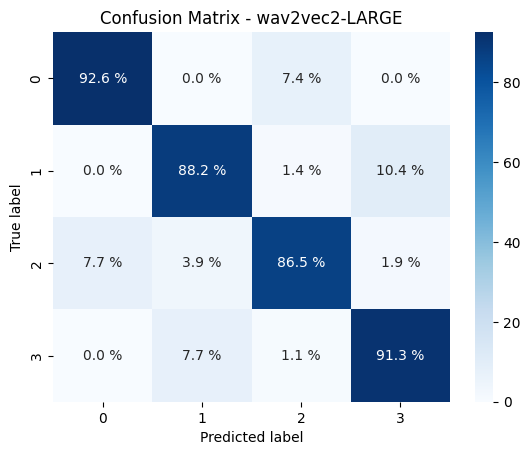

In [5]:
layer_num=1
combined_cm = None
for layer, fold, cm in confusion_matrices:
    if layer_num is None or layer == layer_num:
        if combined_cm is None:
            combined_cm = cm
        else:
            combined_cm += cm

if combined_cm is not None:
    # Calculate percentages
    cm_sum = np.sum(combined_cm, axis=1, keepdims=True)
    combined_cm_percentage = np.round(100 * combined_cm / cm_sum, 2)

    plt.figure()
    plot = sns.heatmap(combined_cm_percentage, annot=True, fmt='.1f', cmap='Blues')
    for t in plot.texts: t.set_text(t.get_text() + " %")
    plt.title(f'Confusion Matrix - wav2vec2-LARGE')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

## Hyper-parameter Tuning

In [6]:
model_name = "wav2vec2large"
layer=1
param_grid = {
    'C': [0.001, 0.01, 0.1],
    'gamma': [0.00001, 0.000001, 0.00001, 0.0001, 0.0001, 0.001, 'scale'],
}

# Perform hyperparameter tuning
best_params, best_score = svm_hyperparameter_tuning(model_name, layer, param_grid)

print("Best hyperparameters:", best_params)
print("Best cross-validation score:", best_score)

Best hyperparameters: {'C': 0.1, 'gamma': 1e-05}
Best cross-validation score: 0.8858617131062951


# Neural Net

In [7]:
wav2vec2large_5fold_nn_df = k_fold_cross_val_nn("wav2vec2large")
wav2vec2large_5fold_nn_df.to_csv('results/wav2vec2large_5fold_nn_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|███████████████| 25/25 [03:16<00:00,  7.87s/it]


# XGB

In [8]:
wav2vec2large_5fold_xgb_df = k_fold_cross_val_xgb("wav2vec2large")
wav2vec2large_5fold_xgb_df.to_csv('results/wav2vec2large_5fold_xgb_df_mean_embd.csv', index=False)

Layer-wise classification: 100%|███████████████| 25/25 [07:31<00:00, 18.06s/it]
